<a href="https://colab.research.google.com/github/clararmbastos-310/MVP-Analise-de-Dados-e-Boas-Praticas-Clara-Bastos/blob/main/MVP_Clara_Bastos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MVP Análise de Dados e Boas Práticas**

**Nome:** Clara Bastos

**Matrícula:** 17780524795

**Dataset:** [Adult Census Income](https://archive.ics.uci.edu/dataset/2/adult)

# Descrição do Problema

O conjunto de dados Adult Census Income consiste em informações demográficas e profissionais de indivíduos. O objetivo principal deste trabalho é classificar esses indivíduos de acordo com sua faixa de renda, buscando compreender quais características influenciam essa variável. O foco da análise é investigar as oportunidades no mercado de trabalho no universo feminino, analisando como diferentes fatores estão associados à faixa de renda das mulheres.

## Hipóteses do Problema

As hipóteses traçadas são:

1. **O gênero influencia a faixa de renda do indivíduo?**

2. **O impacto do nível educacional na faixa de renda é diferente entre homens e mulheres?**

3. **A carga horária semanal de trabalho influencia de forma diferente a renda de homens e mulheres?**

## Tipo de Problema

Este é um problema de **classificação supervisionada**, no qual a variável alvo é a coluna income. Dado um conjunto de características demográficas e profissionais dos indivíduos, o objetivo é prever a faixa de renda (maior ou menor que 50k).



## Seleção de Dados

O dataset Adult Census Income Dataset já se encontrava disponível para uso, não sendo necessária uma etapa de seleção externa de dados. No entanto, foram considerados apenas indivíduos cujo país de origem é os Estados Unidos, com o objetivo de tornar a análise mais consistente em relação ao contexto socioeconômico. Além disso, algumas variáveis foram desconsideradas por não serem diretamente relevantes para os objetivos da análise, como a variável fnlwgt, que representa um peso amostral, e a variável education-num, por ser redundante em relação à variável categórica education. Essas seleções e ajustes serão implementados nas etapas seguintes do notebook, durante o carregamento e preparação dos dados.

# Importação das Bibliotecas Necessárias e Carga de Dados


In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE


In [72]:
#importando url com dados para um dataframe
url_dados = "https://raw.githubusercontent.com/clararmbastos-310/MVP-Analise-de-Dados-e-Boas-Praticas-Clara-Bastos/refs/heads/main/Base%20de%20Dados/adult.data"

#labels dos atributos do dataset
labels_atributos = ["age", "workclass", "fnlwgt", "education", "education-num",
                    "marital-status", "occupation", "relationship", "race", "sex",
                    "capital-gain", "capital-loss", "hours-per-week","native-country", "income"]

df = pd.read_csv(url_dados,names=labels_atributos)

#exibindo últimas linhas
df.tail()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


In [73]:
#Seleção de Dados descrita na seção descrita acima:

#Selecionando apenas os dados em que o país de origem é Estados Unidos:
df_mvp = df[df['native-country'] == ' United-States']

#Excluindo as colunas fnlwgt e education-num por não serem relevantes para análise:
df_mvp = df_mvp.drop(columns=['fnlwgt', 'education-num'])

# Reorganizando index:
df_mvp = df_mvp.reset_index(drop=True)

#Exibindo últimas linhas:
df_mvp.tail()

,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
29165,27,Private,Assoc-acdm,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
29166,40,Private,HS-grad,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
29167,58,Private,HS-grad,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
29168,22,Private,HS-grad,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
29169,52,Self-emp-inc,HS-grad,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


#Análise de Dados

Nesta etapa de Análise de Dados Exploratória (EDA) sobre o dataset, visamos entender a distribuição, as relações e as características das variáveis, o que é crucial para as etapas subsequentes de pré-processamento e modelagem.

## Total de Instâncias

O dataset original (df) possuía 32.561 instâncias e 15 atributos. Após a aplicação dos filtros e remoção de variáveis, o dataset resultante (df_mvp) passou a conter 29.170 instâncias e 13 atributos.

O dataset df_mvp possui 4 atributos numéricos e 9 categóricos, que serão descritos na próxima seção.

Observa-se uma distribuição desigual de indivíduos tanto por gênero, havendo maior concentração de homens em relação às mulheres, quanto por faixa de renda, com predominância de indivíduos na categoria de renda inferior ou igual a 50 mil. Esse desbalanceamento pode influenciar as análises realizadas e deve ser considerado nas etapas seguintes do trabalho.

## Atributos do Dataset - Definição e Tipos

* **Age:** Esse atributo representa a idade do indivíduo. É um atributo numérico (int64). Os valores variam de 17 a 90. Não existem valores nulos ou desconhecidos.

* **Workclass:** Esse atributo representa a classe de trabalho do indivíduo. É um atributo categórico. Pode ter os seguintes valores: Private (Setor privado);
Self-emp-not-inc (Autônomo); Self-emp-inc (Empresário); Federal-gov (Governo federal); State-gov (Governo estadual); Local-gov (Governo municipal); Without-pay (Sem remuneração); Never-worked (Nunca trabalhou). Não existem valores nulos, porém existem valores desconhecidos representados por "?".

* **Education:** Esse atributo representa o nível educacional do indivíduo. É um atributo categórico. Pode ter os seguintes valores: Principais valores:
Bachelors (Ensino superior - graduação); Some-college (Faculdade incompleta); HS-grad (Ensino médio completo); Masters (Mestrado); Doctorate (Doutorado);Assoc-acdm (Tecnólogo - acadêmico); Assoc-voc (Tecnólogo - profissionalizante); 1th - 12th (Ensino médio incompleto); Preschool (Pré-escolar). Não existem valores nulos ou desconhecidos.

* **Marital_Status:** Esse atributo representa o estado civil do indivíduo. É um atributo categórico. Pode ter os seguintes valores: Married-civ-spouse (Casado); Divorced (Divorciado); Never-married (Nunca casado); Separated (Separado); Widowed (Viúvo); Married-spouse-absent (Casado(a), mas sem o cônjuge presente). Não existem valores nulos ou desconhecidos.

* **Occupation:** Esse atributo representa a ocupação do indivíduo. É um atributo categórico. Pode ter os seguintes valores: Tech-support (Suporte técnico); Craft-repair (Reparos/manutenção); Exec-managerial (Executivo/gerencial); Sales (Vendas); Adm-clerical (Administrativo); Handlers-cleaners (Serviços gerais);
Machine-op-inspct (Operador de máquinas); Prof-specialty (Profissional especializado); Other-service (Outros serviços); Transport-moving (Transporte); Farming-fishing (Agricultura/pesca);Protective-serv (Segurança); Priv-house-serv (Serviço doméstico); Armed-Forces (Forças armadas). Não existem valores nulos, porém existem valores desconhecidos representados por "?".

* **Relationship:** Esse atributo representa a relação familiar do indivíduo. É um atributo categórico. Pode ter os seguintes valores: Husband (Marido); Wife (Esposa); Own-child (Filho); Not-in-family (Não pertence a núcleo familiar); Other-relative (Outro parente); Unmarried (Não casado). Não existem valores nulos ou desconhecidos.

* **Race:** Esse atributo representa a raça do indivíduo. É um atributo categórico. Pode ter os seguintes valores: White (Branco); Black (Negro);
Asian-Pac-Islander (Asiático/Ilhas do Pacífico);Amer-Indian-Eskimo (Indígena americano/esquimó);
Other (Outro). Não existem valores nulos ou desconhecidos.

* **Sex:** Esse atributo representa o gênero do indivíduo. É um atributo categórico. Pode ter os seguintes valores: Male (Masculino); Female (Feminino). Não existem valores nulos ou desconhecidos.

* **Capital-gain:** Esse atributo representa os ganhos de capital do indivíduo. É um atributo numérico (int64). Os valores variam de 0 a 99999. Não existem valores nulos ou desconhecidos.

* **Capital-loss:** Esse atributo representa as perdas de capital do indivíduo. É um atributo numérico (int64). Os valores variam de 0 a 4356. Não existem valores nulos ou desconhecidos.

* **Hours-per-week:** Esse atributo representa as horas trabalhadas por semana do indivíduo. É um atributo numérico (int64). Os valores variam de 1 a 99. Não existem valores nulos ou desconhecidos.

* **Native Country:** Esse atributo representa o país de origem do indivíduo. É um atributo categórico. Pela seleção de dados, foram considerados (filtrados) apenas o país de origem United-States. horas trabalhas por semana do indivíduo. Não existem valores nulos ou desconhecidos.

* **Income:** Esse atributo representa a faixa de renda do indivíduo. É a variável alvo da análise. É um atributo categórico. Os valores são: <=50K (Até 50 mil); >50K (Acima de 50 mil). Não existem valores nulos ou desconhecidos.

**Observação:** Algumas colunas presentes no dataset original foram removidas após a etapa de seleção de dados, por não serem relevantes para a análise proposta. Essas colunas estão presentes apenas no dataframe original (df).

* **Fnlwgt:** Esse atributo representa o peso amostral atributo ao indivíduo considerando suas características. É um atributo numérico (int64). Não existem valores nulos ou desconhecidos.

* **Education_Num:** Esse atributo representa a quantidade de anos de estudo. É um atributo numérico (int64). Os valores variam de 1 a 16. Não existem valores nulos ou desconhecidos.







In [74]:
#Informações dataset original
print(f"Total de instâncias: {len(df)}")
print("\nTipos de dados por coluna:")
print(df.info())

Total de instâncias: 32561

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB
None


In [75]:
#Informações do dataset com a seleção de dados do mvp
print(f"Total de instâncias: {len(df_mvp)}")
print("\nTipos de dados por coluna:")
print(df_mvp.info())

Total de instâncias: 29170

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29170 entries, 0 to 29169
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             29170 non-null  int64 
 1   workclass       29170 non-null  object
 2   education       29170 non-null  object
 3   marital-status  29170 non-null  object
 4   occupation      29170 non-null  object
 5   relationship    29170 non-null  object
 6   race            29170 non-null  object
 7   sex             29170 non-null  object
 8   capital-gain    29170 non-null  int64 
 9   capital-loss    29170 non-null  int64 
 10  hours-per-week  29170 non-null  int64 
 11  native-country  29170 non-null  object
 12  income          29170 non-null  object
dtypes: int64(4), object(9)
memory usage: 2.9+ MB
None


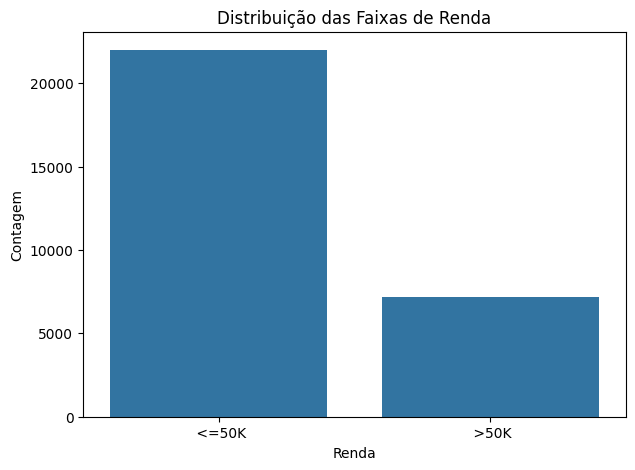

In [76]:
#Distribuição das Faixas de Renda - Variável Alvo
plt.figure(figsize=(7, 5))
sns.countplot(x='income', data=df_mvp)
plt.title('Distribuição das Faixas de Renda')
plt.xlabel('Renda')
plt.ylabel('Contagem')
plt.show()

O gráfico mostra um desbalanceamento do dataset em termos de faixa de renda. Existe uma maior concentração de indivíduos na faixa de <=50K em relação a faixa de >50k.

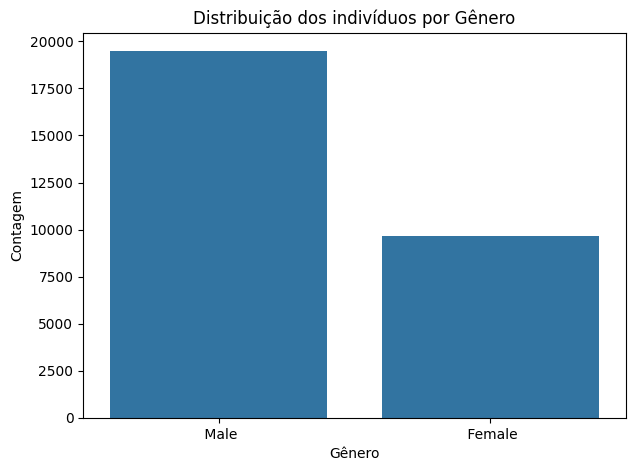

In [77]:
#Distribuição do Gênero
plt.figure(figsize=(7, 5))
sns.countplot(x='sex', data=df_mvp)
plt.title('Distribuição dos indivíduos por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Contagem')
plt.show()

Além da análise de balanceamento da variável alvo, foi realizada uma análise da distribuição da variável sex (gênero), considerando o tema do trabalho. Existe uma maior concentração de homens.

##Há valores faltantes, discrepantes ou inconsistentes?

### Análise das primeiras linhas do dataset

In [78]:
#Verificando as primeiras linhas do dataset
df_mvp.head()

,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,37,Private,Masters,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K


Pelas primeiras linhas do dataset não foi possível identificar valores inconsistentes.

In [79]:
#Analisando atributos categóricos:
for col in df_mvp.select_dtypes(include='object').columns:
    print(f"\nColuna: {col}")
    print(df_mvp[col].unique())


Coluna: workclass
[' State-gov' ' Self-emp-not-inc' ' Private' ' Federal-gov' ' Local-gov'
 ' Self-emp-inc' ' ?' ' Without-pay' ' Never-worked']

Coluna: education
[' Bachelors' ' HS-grad' ' 11th' ' Masters' ' Some-college' ' Assoc-acdm'
 ' Doctorate' ' 9th' ' Assoc-voc' ' 10th' ' 7th-8th' ' Prof-school'
 ' 1st-4th' ' Preschool' ' 5th-6th' ' 12th']

Coluna: marital-status
[' Never-married' ' Married-civ-spouse' ' Divorced' ' Separated'
 ' Married-AF-spouse' ' Widowed' ' Married-spouse-absent']

Coluna: occupation
[' Adm-clerical' ' Exec-managerial' ' Handlers-cleaners' ' Prof-specialty'
 ' Sales' ' Farming-fishing' ' Machine-op-inspct' ' Other-service'
 ' Transport-moving' ' Tech-support' ' Craft-repair' ' Protective-serv'
 ' ?' ' Armed-Forces' ' Priv-house-serv']

Coluna: relationship
[' Not-in-family' ' Husband' ' Wife' ' Own-child' ' Unmarried'
 ' Other-relative']

Coluna: race
[' White' ' Black' ' Other' ' Asian-Pac-Islander' ' Amer-Indian-Eskimo']

Coluna: sex
[' Male' ' Female']

Ao analisar as variáveis categóricas, foram identificados espaços em branco antes dos valores, além da presença de “?” nas colunas "workclass" e "occupation" representando valores desconhecidos.

### Resumo Estatísco - Estatísticas Descritivas

In [80]:
#Estatísticas descritivas básicas do dataset
df_mvp.describe()

,age,capital-gain,capital-loss,hours-per-week
count,29170.000000,29170.000000,29170.000000,29170.000000
mean,38.655674,1089.229928,88.510593,40.447755
std,13.722408,7381.898528,405.681709,12.417203
min,17.000000,0.000000,0.000000,1.000000
25%,28.000000,0.000000,0.000000,40.000000
50%,37.000000,0.000000,0.000000,40.000000
75%,48.000000,0.000000,0.000000,45.000000
max,90.000000,99999.000000,4356.000000,99.000000


In [81]:
#Analisando a moda dos atributos
for col in df_mvp.select_dtypes(include='int64').columns:
    print(f"\nColuna: {col}")
    print(df_mvp[col].mode())


Coluna: age
0    36
Name: age, dtype: int64

Coluna: capital-gain
0    0
Name: capital-gain, dtype: int64

Coluna: capital-loss
0    0
Name: capital-loss, dtype: int64

Coluna: hours-per-week
0    40
Name: hours-per-week, dtype: int64


In [82]:
#Número de valores ausentes
df_mvp.isnull().sum()

,0
age,0
workclass,0
education,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0
capital-gain,0
capital-loss,0


In [83]:
#Número de valores '?'
(df_mvp==' ?').sum()

,0
age,0
workclass,1659
education,0
marital-status,0
occupation,1666
relationship,0
race,0
sex,0
capital-gain,0
capital-loss,0


Foram analisadas as estatísticas descritivas das variáveis numéricas por meio do método describe(), permitindo identificar medidas de tendência central, dispersão e possíveis valores extremos. Além disso, foi realizada a análise da moda e dos valores nulos e desconhecidos.

A partir dessa análise, observou-se a presença de distribuições assimétricas e possíveis outliers, especialmente nas variáveis capital-gain e capital-loss. Essas variáveis apresentam forte concentração de valores em zero e poucos valores extremamente elevados. A variável hours-per-week, apresentou valores extremos (mínimo de 1 e máximo de 99 horas semanais). Já a variável age não apresentou inconsistências aparentes.

Não foram identificados valores ausentes no dataset. No entanto, foram encontrados valores “?” em algumas variáveis categóricas (workclass e occupation), representando dados desconhecidos, os quais serão tratados na etapa de pré-processamento.

### Visualizações

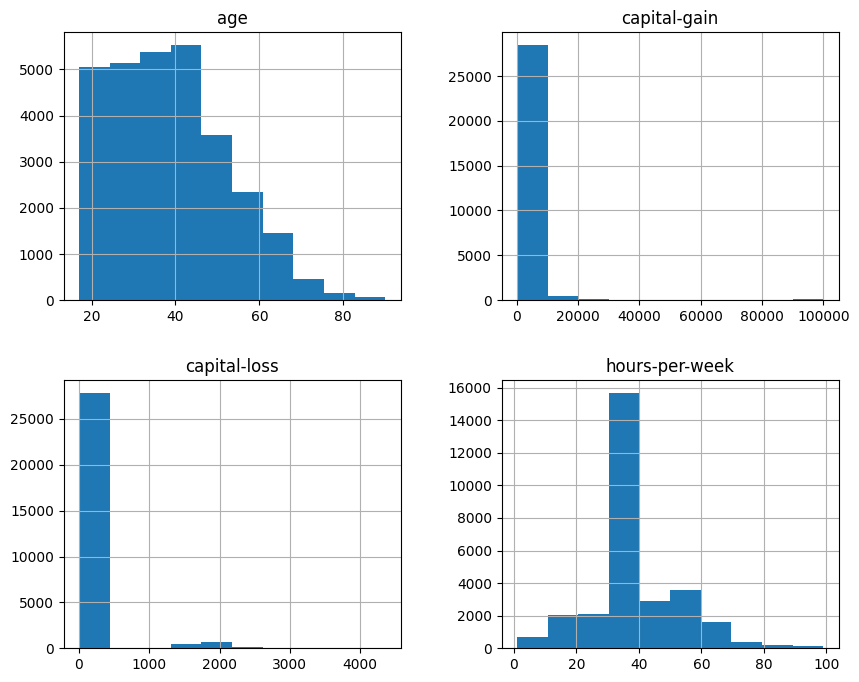

In [84]:
#Distribuição Atributos Numéricos:
df_mvp.hist(figsize=(10,8))
plt.show()

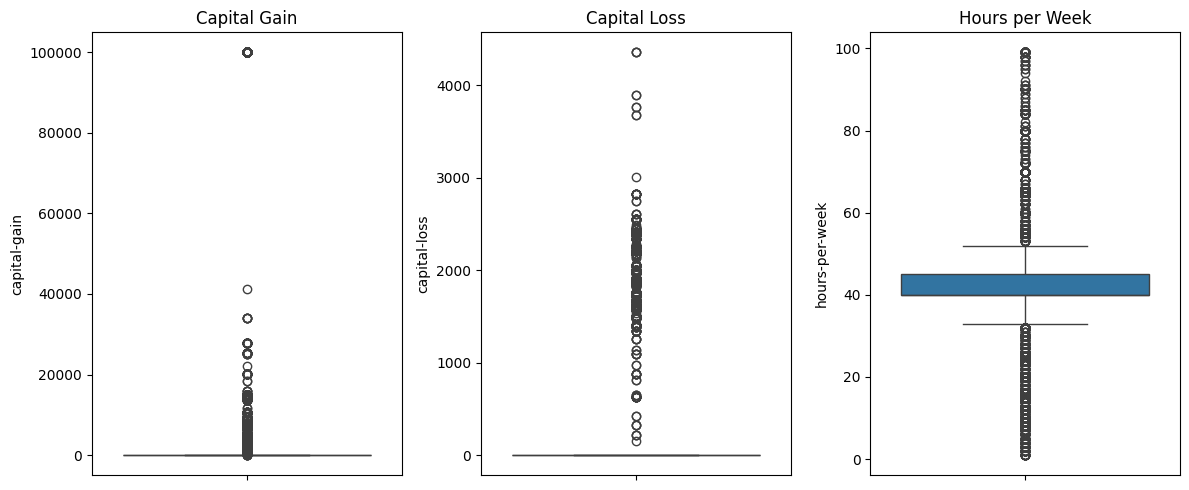

In [85]:
#Boxplot - Análise das variáveis Capital Gain, Capital Loss e Hours per Week - Outliers
fig, ax = plt.subplots(1, 3, figsize=(12,5))

#Capital Gain
sns.boxplot(y='capital-gain', data=df_mvp, ax=ax[0])
ax[0].set_title('Capital Gain')

#Capital Loss
sns.boxplot(y='capital-loss', data=df_mvp, ax=ax[1])
ax[1].set_title('Capital Loss')

#Hours per week
sns.boxplot(y='hours-per-week', data=df_mvp, ax=ax[2])
ax[2].set_title('Hours per Week')

plt.tight_layout()
plt.show()

As variáveis capital-gain e capital-loss apresentam distribuições altamente assimétricas, com grande concentração de valores em zero e poucos valores elevados. A variável hours-per-week apresenta concentração em torno de 40 horas semanais, com alguns valores extremos. Já a variável age apresenta distribuição mais equilibrada, sem grandes concentrações extremas.

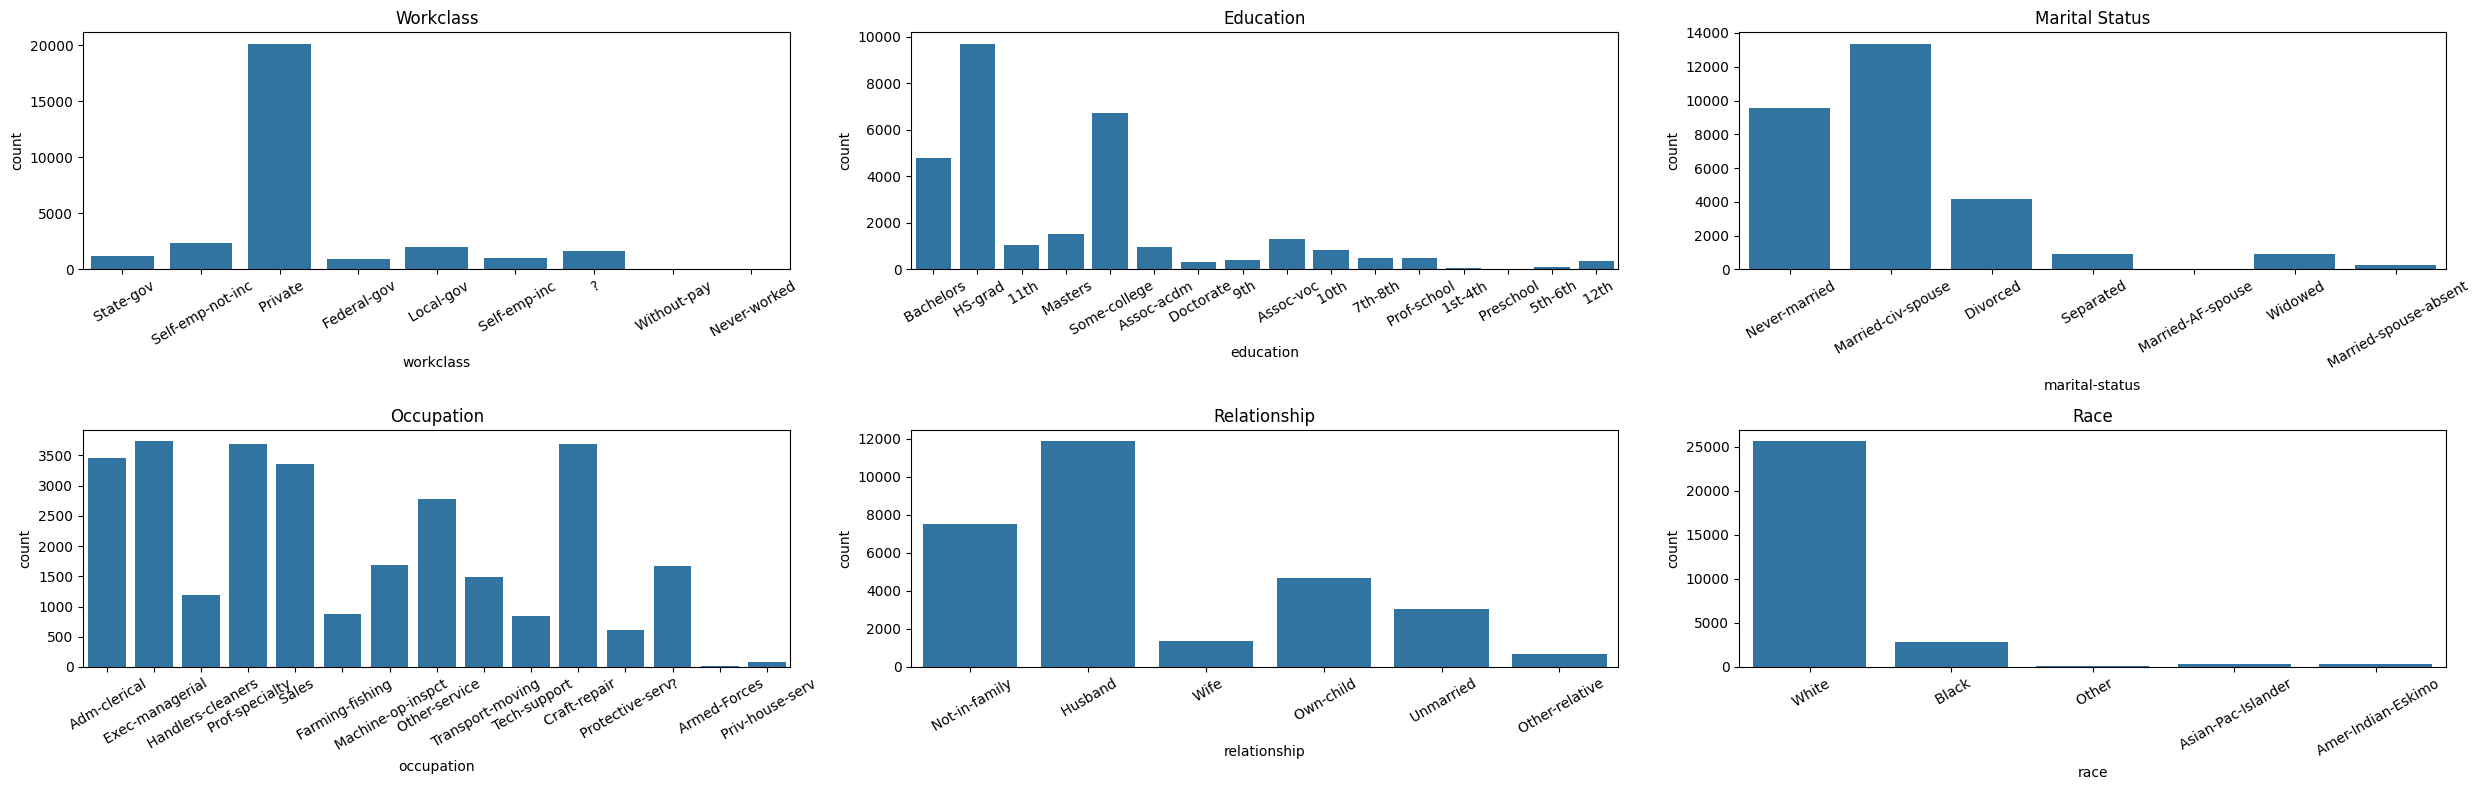

In [86]:
#Distribuição variáveis categóricas
fig, ax = plt.subplots(2, 3, figsize=(25,8))

#Workclass
sns.countplot(x='workclass', data=df_mvp, ax=ax[0,0])
ax[0,0].set_title('Workclass')
ax[0,0].tick_params(axis='x', rotation=30)

#Education
sns.countplot(x='education', data=df_mvp, ax=ax[0,1])
ax[0,1].set_title('Education')
ax[0,1].tick_params(axis='x', rotation=30)

#Marital-status
sns.countplot(x='marital-status', data=df_mvp, ax=ax[0,2])
ax[0,2].set_title('Marital Status')
ax[0,2].tick_params(axis='x', rotation=30)

#Occupation
sns.countplot(x='occupation', data=df_mvp, ax=ax[1,0])
ax[1,0].set_title('Occupation')
ax[1,0].tick_params(axis='x', rotation=30)

#Relationship
sns.countplot(x='relationship', data=df_mvp, ax=ax[1,1])
ax[1,1].set_title('Relationship')
ax[1,1].tick_params(axis='x', rotation=30)

#Race
sns.countplot(x='race', data=df_mvp, ax=ax[1,2])
ax[1,2].set_title('Race')
ax[1,2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()





As variáveis income e sex já foram avaliadas anteriormente, evidenciando desbalanceamento em suas distribuições. A variável native-country não foi considerada nesta etapa, uma vez que o dataset foi previamente filtrado para conter apenas registros dos Estados Unidos. Observa-se que as variáveis categóricas apresentam distribuições desbalanceadas, com predominância de algumas categorias, como Private em workclass, HS-grad em education, indivíduos casados em marital-status e a categoria White em race.

In [87]:
#Matriz de correlação
print("\nMatriz de Correlação:")
df_mvp.corr(numeric_only=True)


Matriz de Correlação:


,age,capital-gain,capital-loss,hours-per-week
age,1.000000,0.077409,0.057485,0.071453
capital-gain,0.077409,1.000000,-0.032194,0.078478
capital-loss,0.057485,-0.032194,1.000000,0.051498
hours-per-week,0.071453,0.078478,0.051498,1.000000


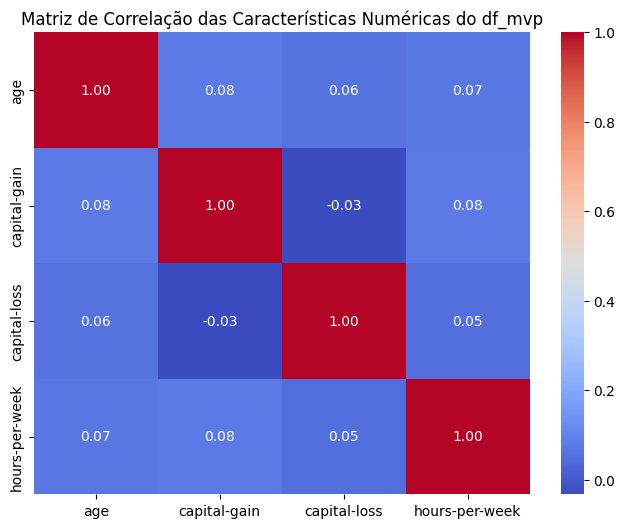

In [88]:
#Mapa de calor das variáveis numéricas:
plt.figure(figsize=(8, 6))
sns.heatmap(df_mvp.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Características Numéricas do df_mvp')
plt.show()

A matriz de correlação indica baixa correlação linear entre as variáveis numéricas, com valores próximos de zero, sugerindo ausência de relações lineares significativas entre elas.

# Pré-Pocessamento de Dados

O pré-processamento de dados é uma etapa crucial para preparar os dados para modelagem, garantindo que estejam no formato correto e otimizados para o desempenho do algoritmo.

Como verificado anteriormente na etapa de análise de dados, as variáveis categóricas apresentavam espaços no início dos valores. Dessa forma, foi realizada a remoção desses espaços em branco, a fim de evitar inconsistências na representação das categorias.

## Limpeza de Dados

In [89]:
#Ajustando escrita variáveis categóricas:
for col in df_mvp.select_dtypes(include='object'):
    df_mvp[col] = df_mvp[col].str.strip()

In [90]:
#Nova análise atributos categóricos:
for col in df_mvp.select_dtypes(include='object').columns:
    print(f"\nColuna: {col}")
    print(df_mvp[col].unique())


Coluna: workclass
['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov'
 'Self-emp-inc' '?' 'Without-pay' 'Never-worked']

Coluna: education
['Bachelors' 'HS-grad' '11th' 'Masters' 'Some-college' 'Assoc-acdm'
 'Doctorate' '9th' 'Assoc-voc' '10th' '7th-8th' 'Prof-school' '1st-4th'
 'Preschool' '5th-6th' '12th']

Coluna: marital-status
['Never-married' 'Married-civ-spouse' 'Divorced' 'Separated'
 'Married-AF-spouse' 'Widowed' 'Married-spouse-absent']

Coluna: occupation
['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Sales' 'Farming-fishing' 'Machine-op-inspct' 'Other-service'
 'Transport-moving' 'Tech-support' 'Craft-repair' 'Protective-serv' '?'
 'Armed-Forces' 'Priv-house-serv']

Coluna: relationship
['Not-in-family' 'Husband' 'Wife' 'Own-child' 'Unmarried' 'Other-relative']

Coluna: race
['White' 'Black' 'Other' 'Asian-Pac-Islander' 'Amer-Indian-Eskimo']

Coluna: sex
['Male' 'Female']

Coluna: native-country
['United-States']

Coluna: income
['

## Tratamento valores nulos e desconhecidos

Como visto anteriormente na seção de Análise de Dados, em Resumo Estatístico - Estatísticas Descritivas, a base de dados não apresenta valores nulos, apenas valores desconhecidos representados por "?". Esses valores '?' aparecem nas colunas "workclass", com 1659 registros e "occcupation", com 1666 registritos

In [91]:
#Verificando em quantas linhas o valor '?' aparece para as duas colunas - workclass e occupation
((df_mvp['workclass'] == '?') & (df_mvp['occupation'] == '?')).sum()

np.int64(1659)

Observou-se que, em 1.659 instâncias, os valores desconhecidos "?" ocorrem simultaneamente nas variáveis workclass e occupation. Além disso, existem 7 registros em que o valor "?" aparece apenas na variável occupation. Assim, totalizam-se 1.666 instâncias na base com presença de valores desconhecidos.

Considerando que o dataset possui 29.170 instâncias, esse valor representa aproximadamente 5% da base. Dessa forma, optou-se pela remoção dessas linhas, por se tratar de uma proporção relativamente pequena, sendo considerada aceitável.

In [92]:
#Desconsiderando as linhas com valores '?'
df_mvp = df_mvp[(df_mvp['workclass'] != '?') & (df_mvp['occupation'] != '?')]

In [93]:
#Informações dataset mvp com a retirada desses valores
print(f"Total de instâncias: {len(df_mvp)}")
print("\nTipos de dados por coluna:")
print(df_mvp.info())

Total de instâncias: 27504

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
Index: 27504 entries, 0 to 29169
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             27504 non-null  int64 
 1   workclass       27504 non-null  object
 2   education       27504 non-null  object
 3   marital-status  27504 non-null  object
 4   occupation      27504 non-null  object
 5   relationship    27504 non-null  object
 6   race            27504 non-null  object
 7   sex             27504 non-null  object
 8   capital-gain    27504 non-null  int64 
 9   capital-loss    27504 non-null  int64 
 10  hours-per-week  27504 non-null  int64 
 11  native-country  27504 non-null  object
 12  income          27504 non-null  object
dtypes: int64(4), object(9)
memory usage: 2.9+ MB
None


## Divisão do dataset em Treino e Teste

In [94]:
#Separar features (X) e target (y)
X = df_mvp.drop('income', axis=1)
y = df_mvp['income']

In [95]:
#Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [96]:
print(f"Dimensões de X_train: {X_train.shape}")
print(f"Dimensões de X_test: {X_test.shape}")
print(f"Dimensões de y_train: {y_train.shape}")
print(f"Dimensões de y_test: {y_test.shape}")

Dimensões de X_train: (19252, 12)
Dimensões de X_test: (8252, 12)
Dimensões de y_train: (19252,)
Dimensões de y_test: (8252,)


## Tratamento de Outliers




Como observado na etapa de análise exploratória, as variáveis capital-gain, capital-loss e hours-per-week apresentam valores extremos que podem ser caracterizados como outliers. Dessa forma, nesta etapa será realizado o tratamento desses valores, a fim de evitar possíveis impactos negativos no desempenho dos modelos de aprendizado de máquina.

In [97]:
#Análise limites variável capital-gain
Q1_cg = X_train['capital-gain'].quantile(0.25)
Q3_cg = X_train['capital-gain'].quantile(0.75)
IQR_cg = Q3_cg - Q1_cg

limite_inferior_cg = Q1_cg - 1.5 * IQR_cg
limite_superior_cg = Q3_cg + 1.5 * IQR_cg

print(f"\nLimite Inferior: {limite_inferior_cg}")
print(f"\nLimite Inferior: {limite_superior_cg}")



Limite Inferior: 0.0

Limite Inferior: 0.0


In [98]:
#Análise limites variável capital-loss
Q1_cl = X_train['capital-loss'].quantile(0.25)
Q3_cl = X_train['capital-loss'].quantile(0.75)
IQR_cl = Q3_cl - Q1_cl

limite_inferior_cl = Q1_cl - 1.5 * IQR_cl
limite_superior_cl = Q3_cl + 1.5 * IQR_cl

print(f"\nLimite Inferior: {limite_inferior_cl}")
print(f"\nLimite Inferior: {limite_superior_cl}")


Limite Inferior: 0.0

Limite Inferior: 0.0


As variáveis "capital_gain" e "capital_loss" apresentaram alta concentração de valores iguais a zero e poucos valores elevados, caracterizando distribuição assimétrica. Esses valores representam eventos raros, porém válidos, e portanto optou-se por não aplicar tratamento de outliers, a fim de não distorcer a distribuição original dos dados.

In [99]:
#Análise limites hours-per-week
Q1_h = X_train['hours-per-week'].quantile(0.25)
Q3_h = X_train['hours-per-week'].quantile(0.75)
IQR_h = Q3_h - Q1_h

limite_inferior_h = Q1_h - 1.5 * IQR_h
limite_superior_h = Q3_h + 1.5 * IQR_h

print(f"\nLimite Inferior: {limite_inferior_h}")
print(f"\nLimite Inferior: {limite_superior_h}")


Limite Inferior: 32.5

Limite Inferior: 52.5


In [100]:
#Aplicar limites no treino
X_train['hours-per-week'] = np.where(
    X_train['hours-per-week'] < limite_inferior_h,
    limite_inferior_h,
    X_train['hours-per-week'])

X_train['hours-per-week'] = np.where(
    X_train['hours-per-week'] > limite_superior_h,
    limite_superior_h,
    X_train['hours-per-week'])

In [101]:
#Aplicar limites no treino
X_test['hours-per-week'] = np.where(
    X_test['hours-per-week'] < limite_inferior_h,
    limite_inferior_h,
    X_test['hours-per-week'])

X_test['hours-per-week'] = np.where(
    X_test['hours-per-week'] > limite_superior_h,
    limite_superior_h,
    X_test['hours-per-week'])

In [102]:
#Chegando a aplicação dos limites
print(X_train['hours-per-week'].min())
print(X_train['hours-per-week'].max())

32.5
52.5


A variável "hours-per-week" apresentou valores extremos que podem indicar comportamentos atípicos. Para o tratamento de outliers, foi aplicada a técnica de IQR (Intervalo Interquartil), com abordagem de capping, na qual os valores foram limitados com base nos limites inferior e superior definidos a partir dos quartis.

## Transformação variáveis categóricas

As variáveis categóricas foram transformadas em variáveis numéricas por meio da técnica de one-hot encoding. Esse processo consiste em criar colunas binárias (0 ou 1) para cada categoria existente, permitindo que os algoritmos de machine learning, que não lidam diretamente com dados textuais, possam utilizar essas informações.

A transformação foi aplicada separadamente nos conjuntos de treino e teste, após a divisão dos dados, evitando vazamento de informação (data leakage).

In [103]:
#Criando uma variável para representar as variáveis categóricas
variaveis_categoricas = X_train.select_dtypes(include='object').columns
print(variaveis_categoricas)

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country'],
      dtype='object')


In [104]:
#One-hot-encoding para transformar as variáveis categóricas em numéricas
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_categoricas = encoder.fit_transform(X_train[variaveis_categoricas])
X_test_categoricas = encoder.transform(X_test[variaveis_categoricas])

In [105]:
#Retirar do treino e teste as variaveis categóricas
X_train_num = X_train.drop(columns=variaveis_categoricas)
X_test_num = X_test.drop(columns=variaveis_categoricas)

In [106]:
#Adicionar a treino e teste as variáveis tratadas (transformadas de categóricas para numéricas)
X_train_cat = pd.DataFrame(X_train_categoricas, index=X_train.index)
X_test_cat = pd.DataFrame(X_test_categoricas, index=X_test.index)

In [107]:
#Juntando as informações corretas no dataset
X_train = pd.concat([X_train_num, X_train_cat], axis=1)
X_test = pd.concat([X_test_num, X_test_cat], axis=1)

In [108]:
#Coferindo se a transformação foi feita corretamente em treino e teste
print(X_train.select_dtypes(include='object').columns)

Index([], dtype='object')


## Padronização

Após a transformação das variáveis categóricas, foi aplicada a padronização dos dados por meio do StandardScaler, com o objetivo de ajustar a escala das variáveis numéricas. O ajuste foi realizado utilizando apenas os dados de treino, sendo posteriormente aplicado ao conjunto de teste, evitando vazamento de dados.

In [109]:
#Inicializar o StandardScaler
scaler_std = StandardScaler()

In [110]:
#Selecionar apenas as colunas numéricas
variaveis_numericas = ['age', 'capital-gain', 'capital-loss', 'hours-per-week']

# Aprender média e desvio padrão APENAS de X_train
scaler_std.fit(X_train[variaveis_numericas])

# Padronizar apenas as colunas numéricas
X_train_standardized = scaler_std.transform(X_train[variaveis_numericas])

# Usar a média e o desvio padrão aprendidos de X_train
X_test_standardized = scaler_std.transform(X_test[variaveis_numericas])

In [111]:
#Criar DataFrame para os dados padronizados
df_mvp_standardized = pd.DataFrame(X_train_standardized, columns=variaveis_numericas)
#Exibir as primeiras linhas dos dados padronizados
print("\nPrimeiras 5 linhas dos dados padronizados (treino):")
print(df_mvp_standardized.head())


Primeiras 5 linhas dos dados padronizados (treino):
        age  capital-gain  capital-loss  hours-per-week
0 -1.099255     -0.150827     -0.220455       -0.235376
1 -0.414855      0.466447     -0.220455       -1.047028
2 -0.719033     -0.150827     -0.220455       -0.235376
3  0.497678     -0.150827     -0.220455       -1.452853
4 -0.490900     -0.150827     -0.220455        1.387928


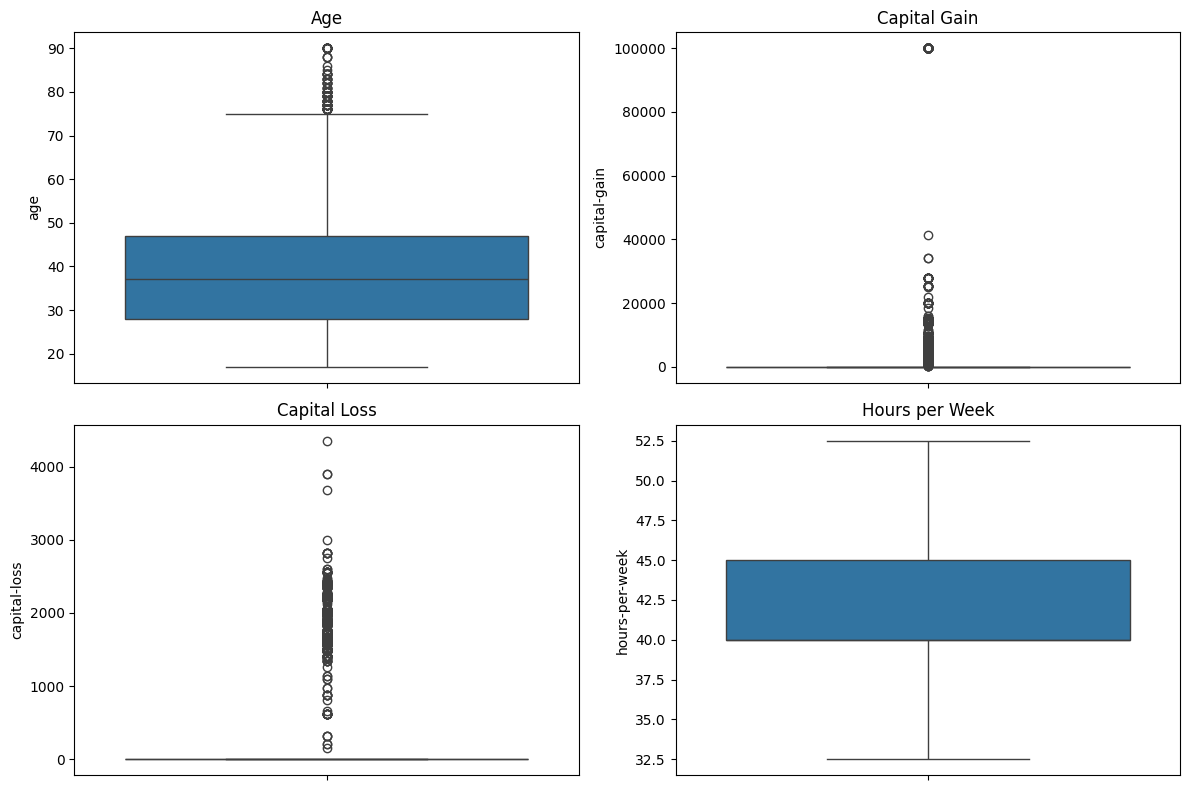

In [112]:
#Visulização pós padronização - Boxplot
fig, ax = plt.subplots(2, 2, figsize=(12,8))

#Age
sns.boxplot(y=X_train['age'], ax=ax[0,0])
ax[0,0].set_title('Age')

#Capital Gain
sns.boxplot(y=X_train['capital-gain'], ax=ax[0,1])
ax[0,1].set_title('Capital Gain')

#Capital Loss
sns.boxplot(y=X_train['capital-loss'], ax=ax[1,0])
ax[1,0].set_title('Capital Loss')

#Hours per week
sns.boxplot(y=X_train['hours-per-week'], ax=ax[1,1])
ax[1,1].set_title('Hours per Week')

plt.tight_layout()
plt.show()

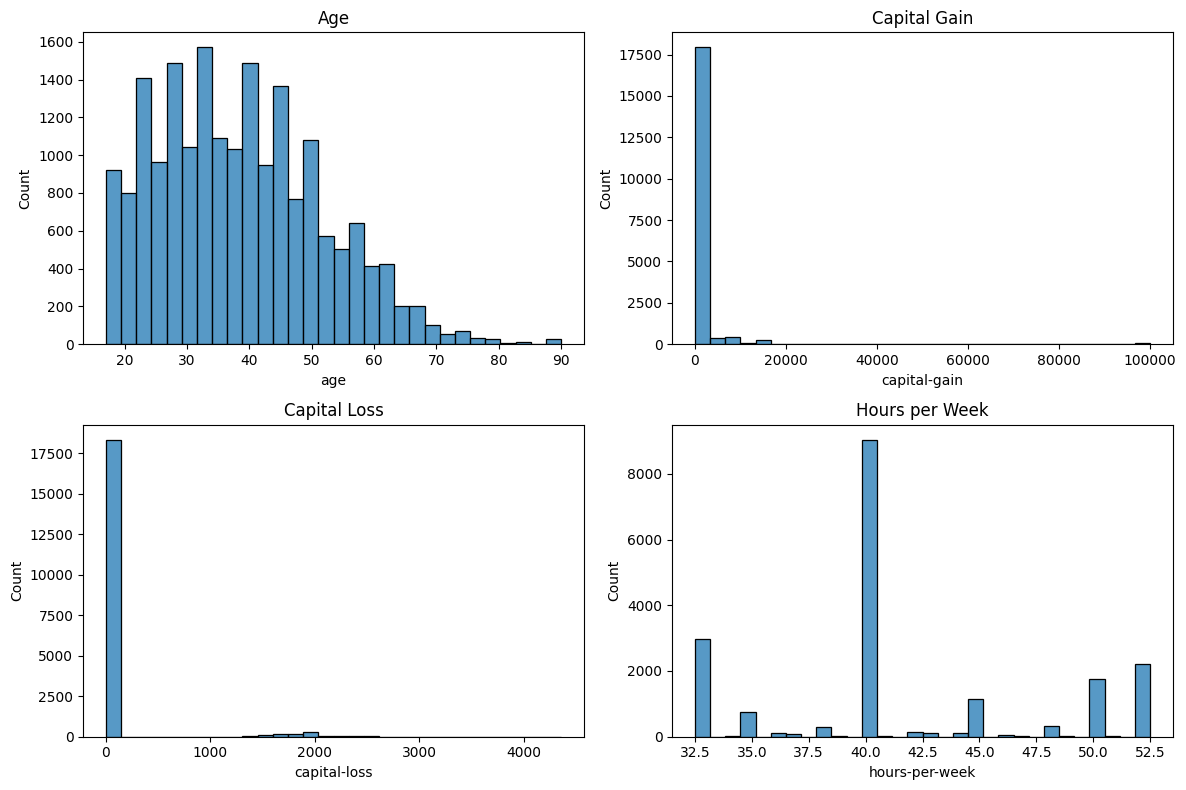

In [113]:
#Visulização pós padronização - Histograma
fig, ax = plt.subplots(2, 2, figsize=(12,8))

#Age
sns.histplot(X_train['age'], bins=30, ax=ax[0,0])
ax[0,0].set_title('Age')

#Capital Gain
sns.histplot(X_train['capital-gain'], bins=30, ax=ax[0,1])
ax[0,1].set_title('Capital Gain')

#Capital Loss
sns.histplot(X_train['capital-loss'], bins=30, ax=ax[1,0])
ax[1,0].set_title('Capital Loss')

#Hours per week
sns.histplot(X_train['hours-per-week'], bins=30, ax=ax[1,1])
ax[1,1].set_title('Hours per Week')

plt.tight_layout()
plt.show()

## Balanceamento

Como visto na etapa de Análise de Dados, a variável alvo income apresenta desbalanceamento, com predominância de indivíduos na faixa de renda menor ou igual a 50 mil. Dessa forma, foi aplicada a técnica SMOTE no conjunto de treino, com o objetivo de equilibrar as classes.

In [114]:
#Tranformando o nome das colunas em texto - Com a transforção das variáveis categóricas em numéricas, algumas colunas ficaram com números no nome
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

In [115]:
#Fazendo o balanceamento de classes - variável alvo 'income'
smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

In [116]:
#Comparação antes x depois balanceamento
print(y_train.value_counts())
print(y_train_bal.value_counts())

income
<=50K    14356
>50K      4896
Name: count, dtype: int64
income
<=50K    14356
>50K     14356
Name: count, dtype: int64


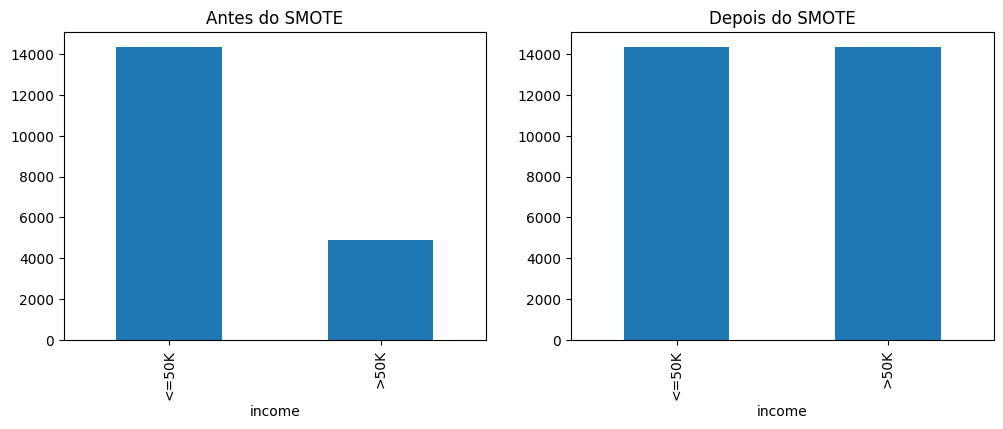

In [117]:
#Visualização antes x depois balanceamento
fig, ax = plt.subplots(1, 2, figsize=(12,4))

#Antes do balanceamento
y_train.value_counts().plot(kind='bar', ax=ax[0])
ax[0].set_title('Antes do SMOTE')

#Depois do balanceamento
y_train_bal.value_counts().plot(kind='bar', ax=ax[1])
ax[1].set_title('Depois do SMOTE')

plt.show()

Após a aplicação do SMOTE, a base de treino passou a apresentar a mesma quantidade de registros para ambas as classes, favorecendo um aprendizado mais equilibrado do modelo.

# Respondendo as hipóteses

## Hipótese 1

O gênero influencia a faixa de renda do indivíduo?

In [118]:
#Criando tabelas cruzadas para entender qual a relação entre as variávies
pd.crosstab(df_mvp['sex'], df_mvp['income'], normalize='index')

income,<=50K,>50K
sex,,
Female,0.885356,0.114644
Male,0.678495,0.321505


Os resultados indicam que aproximadamente 88,5% das mulheres estão na faixa de renda de até 50K, enquanto apenas 11,5% recebem acima desse valor. Por outro lado, entre os homens, cerca de 67,8% estão na faixa de até 50K e 32,2% recebem acima de 50K.

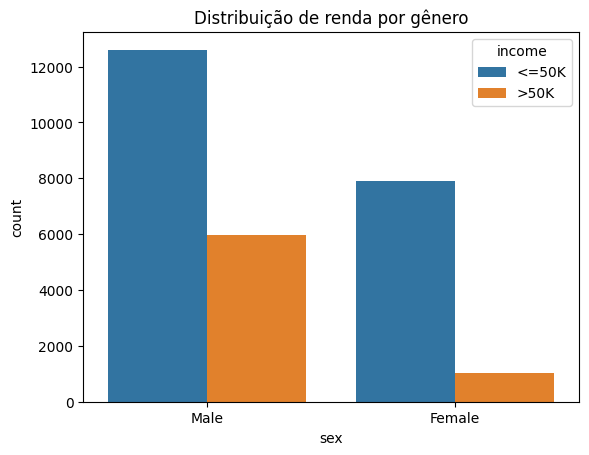

In [119]:
#Visualização Gráfica
sns.countplot(x='sex', hue='income', data=df_mvp)
plt.title('Distribuição de renda por gênero')
plt.show()

Primeiro, foi utilizado um gráfico de contagem para visualizar a distribuição das observações entre gênero e faixa de renda. No entanto, como há diferenças no número total de indivíduos em cada gênero, essa visualização pode dificultar a comparação direta das proporções. Por isso, foi criado um gráfico de barras empilhadas proporcionais, no qual cada gênero é representado na mesma escala (100%). Assim, é possível analisar de forma mais clara a distribuição relativa das faixas de renda dentro de cada grupo.

<Axes: xlabel='sex'>

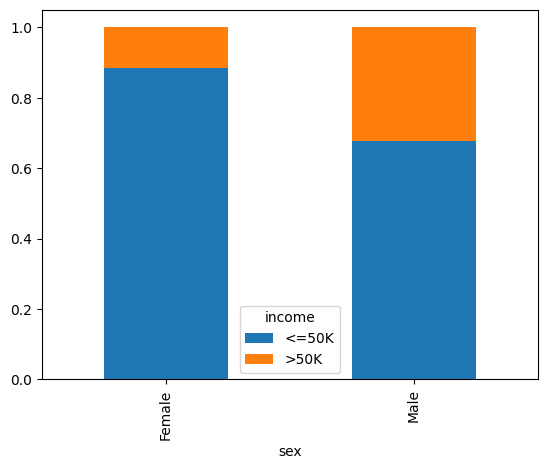

In [120]:
#Visualização Gráfica - Proporcional
prop = pd.crosstab(df_mvp['sex'], df_mvp['income'], normalize='index')
prop.plot(kind='bar', stacked=True)

De acordo com a análise de dados, a hipótese de que o gênero influencia a renda é comprovada. O gênero demonstra ser um influenciador importante na faixa de renda, com mulheres significativamente sub-representadas na categoria de renda superior.

## Hipótese 2

O impacto do nível educacional na faixa de renda é diferente entre homens e mulheres?

In [121]:
#Criando tabelas cruzadas para entender qual a relação entre as variávies
pd.crosstab([df_mvp['sex'], df_mvp['education']], df_mvp['income'], normalize='index')

income                  <=50K      >50K
sex    education                       
Female 10th          0.995633  0.004367
       11th          0.979351  0.020649
       12th          0.981982  0.018018
       1st-4th       1.000000  0.000000
       5th-6th       1.000000  0.000000
       7th-8th       1.000000  0.000000
       9th           0.954023  0.045977
       Assoc-acdm    0.867568  0.132432
       Assoc-voc     0.866822  0.133178
       Bachelors     0.789244  0.210756
       Doctorate     0.373333  0.626667
       HS-grad       0.932221  0.067779
       Masters       0.663202  0.336798
       Preschool     1.000000  0.000000
       Prof-school   0.525641  0.474359
       Some-college  0.926257  0.073743
Male   10th          0.892925  0.107075
       11th          0.922330  0.077670
       12th          0.890909  0.109091
       1st-4th       0.961538  0.038462
       5th-6th       0.952381  0.047619
       7th-8th       0.913947  0.086053
       9th           0.931559  0.068441
       Assoc-acdm    0.662566  0.337434
       Assoc-voc     0.669565  0.330435
       Bachelors     0.480259  0.519741
       Doctorate     0.196653  0.803347
       HS-grad       0.787429  0.212571
       Masters       0.315055  0.684945
       Preschool     1.000000  0.000000
       Prof-school   0.195122  0.804878
       Some-college  0.720491  0.279509

Para avaliar se o impacto do nível educacional na faixa de renda difere entre homens e mulheres, foi inicialmente construída uma tabela cruzada completa entre todas as categorias de escolaridade e gênero. Porém, como o nível educacional apresenta muitas classes, a tabela fica muito grande, pouco intuitiva, dificultando a visualização de padrões relevantes.
Por isso, foram selecionadas os níveis de escolaridades mais altos (Bachelors, Masters, Doctorate e Prof‑school), nas quais as diferenças salariais tendem a se tornar mais evidentes.
Assim, é possível identificar de forma mais objetiva se há disparidades de renda entre homens e mulheres dentro dos níveis educacionais mais elevados.

In [122]:
#Selecionando as categorias de ensino - Níveis de Escolaridade mais altos
df_superior = df_mvp[
    (df_mvp['education'] == 'Bachelors') |
    (df_mvp['education'] == 'Masters') |
    (df_mvp['education'] == 'Doctorate') |
    (df_mvp['education'] == 'Prof-school')]

In [123]:
#Nova tabela cruzada, considerando o nível educacional selecionado
pd.crosstab([df_superior['education'], df_superior['sex']], df_superior['income'], normalize='index')

income                 <=50K      >50K
education   sex                       
Bachelors   Female  0.789244  0.210756
            Male    0.480259  0.519741
Doctorate   Female  0.373333  0.626667
            Male    0.196653  0.803347
Masters     Female  0.663202  0.336798
            Male    0.315055  0.684945
Prof-school Female  0.525641  0.474359
            Male    0.195122  0.804878

<Axes: xlabel='education', ylabel='>50K'>

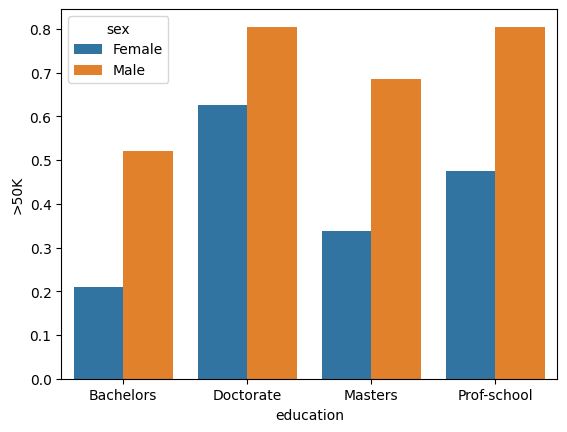

In [124]:
#Visualização gráfica, considerando a proporção dos dados - Assim é possível analisar os gêneros em mesma escala
prop = pd.crosstab([df_superior['education'], df_superior['sex']], df_superior['income'], normalize='index').reset_index()

sns.barplot(data=prop, x='education', y='>50K', hue='sex')

Os dados mostram que o nível educacional melhora a renda média de ambos o gênero, porém, não elimina a diferença salarial entre homens e mulheres. Mesmo dentro de níveis educacionais mais elevados, como Mestrado, Doutorado e Prof-school, as mulheres aparecem com maior proporção na faixa de renda mais baixa, enquanto os homens concentram maior presença na faixa >50K. Isso sugere que, embora a escolaridade avance, o retorno salarial não cresce de maneira equivalente para ambos os gêneros.

## Hipótese 3

A carga horária semanal de trabalho influencia de forma diferente a renda de homens e mulheres?

In [125]:
#Criação de faixas de horas de trabalho
df_mvp['hours_group'] = pd.cut(df_mvp['hours-per-week'], bins=[0, 30, 40, 50, 100], labels=['<=30', '31-40', '41-50', '>50'])

In [126]:
#Tabela cruzada - Sexo vs faixas de horas de trabalho
pd.crosstab([df_mvp['sex'], df_mvp['hours_group']],df_mvp['income'],normalize='index')

income                 <=50K      >50K
sex    hours_group                    
Female <=30         0.939266  0.060734
       31-40        0.894229  0.105771
       41-50        0.775530  0.224470
       >50          0.787629  0.212371
Male   <=30         0.927559  0.072441
       31-40        0.725184  0.274816
       41-50        0.552601  0.447399
       >50          0.539140  0.460860

De acordo com os dados, as mulheres concentram maiores proporções nas faixas de menor renda em todos os grupos de horas, enquanto homens aparecem com probabilidades superiores na renda maior, principalmente em maiores categorias de maiores cargas horárias.

<Axes: xlabel='hours_group', ylabel='>50K'>

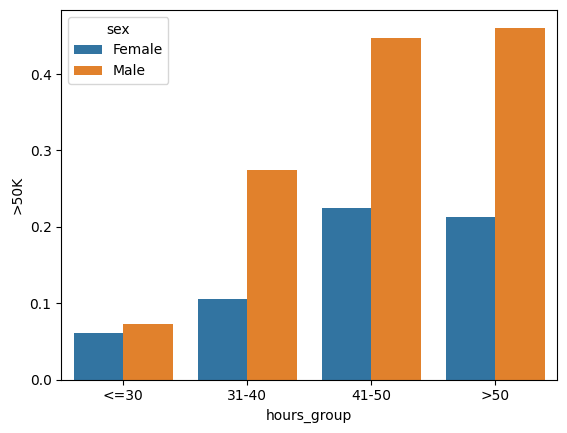

In [127]:
#Visualização gráfica, considerando a proporção dos dados - Assim é possível analisar os gêneros em mesma escala
prop = pd.crosstab([df_mvp['sex'], df_mvp['hours_group']],df_mvp['income'],normalize='index').reset_index()

sns.barplot(data=prop, x='hours_group', y='>50K', hue='sex')

Conforme a carga horária aumenta, cresce também a proporção de indivíduos que alcançam renda acima de 50K. Porém, esse crescimento é maior para homens do que para as mulheres. Em todas as faixas de horas, os homens exibem barras mais altas, indicando maior probabilidade de estarem na faixa de renda elevada. Assim, o gráfico mostra a persistência do diferencial de renda entre os gêneros.

# Conclusão

A análise realizada evidencia que, as mulheres apresentaram probabilidades menores de alcançar a faixa de renda superior a 50 mil.. Em todas as hipóteses testadas, sendo elas o impacto das horas trabalhadas, influência do nível educacional e a interação entre esses fatores com o gênero, os resultados convergiram para o mesmo ponto: o gênero permanece como uma variável determinante para a renda, ainda que não devesse ser.

A análise mostrou mostrou que trabalhar mais não gera, para as mulheres, o mesmo retorno que para os homens. Da mesma forma, o detalhamento por nível educacional revelou que, mesmo entre indivíduos com mestrado, doutorado e formação profissional avançada, as mulheres continuaram recebendo proporcionalmente menos. Ou seja, a qualificação feminina não é traduzida em equidade salarial, indicando que o problema não está na formação, mas na forma como o mercado remunera pessoas de gêneros diferentes por competências semelhantes.

A desigualdade de gênero no mercado de trabalho não é fruto de diferenças individuais, mas de estruturas sistêmicas que limitam o retorno financeiro das mulheres, mesmo quando apresentam igual ou maior qualificação. Superar essas desigualdades exige mais do que políticas pontuais: exige transformação cultural, institucional e organizacional, além de um esforço contínuo para eliminar vieses que ainda hoje moldam a trajetória profissional das mulheres.